# DeepSeek-R1-Distill-Qwen-7B: Corrected BF16 → GGUF Quantization Benchmark

This Colab notebook benchmarks the same model family in this order:

**BF16 → Q8_0 → Q6_K → Q5_K_M → Q4_K_M → Q3_K_M**

Key corrections in this revision:
- deterministic greedy decoding for the primary quantization comparison
- 8,192-token generation budget with explicit `finish_reason`/truncation tracking
- no fallback that mistakes unfinished reasoning for a final answer
- robust MCQ and StrategyQA parsing
- dataset+category stratified sampling with shuffled execution order
- true checkpoint resume within a precision run
- process-tree RAM rather than only system-wide RAM
- model artifact size separated from vLLM/KV-cache GPU allocation
- exact McNemar paired test for BF16↔quantized answer flips
- duplicate `<think>` protection
- GGUF `hf_config_path` using the base HF model

All outputs are written to a new `_v2` Drive directory so older partial runs cannot contaminate the corrected experiment.


## Verify the Colab GPU

Checks that an NVIDIA GPU is attached. PyTorch is intentionally not imported until after package installation to avoid keeping stale CUDA/PyTorch modules in memory.


In [1]:
import subprocess

print(subprocess.check_output(["nvidia-smi", "-L"], text=True))


GPU 0: NVIDIA L4 (UUID: GPU-9637f509-2618-7fb0-0ebc-23c75a27ffe0)



## Install inference and analysis packages

Installs vLLM, the current out-of-tree GGUF plugin, Transformers, and analysis dependencies. In a fresh Colab runtime this cell runs before importing PyTorch/vLLM, avoiding stale package state.


In [2]:
import sys
import subprocess

packages = [
    "vllm",
    "vllm-gguf-plugin",
    "transformers",
    "huggingface_hub",
    "pandas",
    "numpy",
    "scikit-learn",
    "scipy",
    "psutil",
    "sympy",
    "matplotlib",
    "tqdm",
    "pyarrow",
]

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-U", *packages]
)

# Import only after installation.
import torch
import vllm
import transformers

print("vLLM:", vllm.__version__)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA device:", torch.cuda.get_device_name(0))

vLLM: 0.30.0
Transformers: 5.17.0
PyTorch: 2.13.0+cu130
PyTorch CUDA: 13.0
CUDA device: NVIDIA L4


## Mount Google Drive and create the experiment directory

All durable outputs are written under `MyDrive/DeepSeek_R1_7B_Quantization_Benchmark`. If the Colab runtime disconnects, completed precision runs remain available.

In [3]:
from google.colab import drive
from pathlib import Path
import subprocess
import sys

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

RUN_DIR = DRIVE_ROOT / "runs"
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Record exact installed package versions for reproducibility.
freeze_path = DRIVE_ROOT / "pip_freeze.txt"
freeze_path.write_text(
    subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True),
    encoding="utf-8",
)

print("Drive experiment directory:", DRIVE_ROOT)
print("Environment snapshot:", freeze_path)

Mounted at /content/drive
Drive experiment directory: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2
Environment snapshot: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/pip_freeze.txt


## Define the controlled experiment

The primary comparison uses **greedy decoding** (`temperature=0`) so BF16↔quantized answer flips are not confounded by sampling randomness. Generation is allowed up to 8,192 tokens and the model context limit is increased accordingly. Raw GPU usage is retained only as engine telemetry; model artifact size is reported separately because vLLM reserves memory for the KV cache.


In [4]:
from pathlib import Path

BASE_MODEL = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
GGUF_REPO = "second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF"

MODEL_VARIANTS = [
    {"label": "BF16",   "kind": "base", "model": BASE_MODEL, "dtype": "bfloat16"},
    {"label": "Q8_0",   "kind": "gguf", "model": f"{GGUF_REPO}:Q8_0",   "dtype": "auto"},
    {"label": "Q6_K",   "kind": "gguf", "model": f"{GGUF_REPO}:Q6_K",   "dtype": "auto"},
    {"label": "Q5_K_M", "kind": "gguf", "model": f"{GGUF_REPO}:Q5_K_M", "dtype": "auto"},
    {"label": "Q4_K_M", "kind": "gguf", "model": f"{GGUF_REPO}:Q4_K_M", "dtype": "auto"},
    {"label": "Q3_K_M", "kind": "gguf", "model": f"{GGUF_REPO}:Q3_K_M", "dtype": "auto"},
]

SEED = 42

# Primary benchmark = deterministic/greedy to isolate quantization effects.
TEMPERATURE = 0.0
TOP_P = 1.0

# R1-style reasoning can exceed 2k tokens. Track finish_reason and truncation explicitly.
MAX_TOKENS = 8192
MAX_MODEL_LEN = 12288

# This controls vLLM engine/KV-cache reservation. Do NOT interpret nvidia-smi peak
# memory as pure model-weight memory; artifact size is recorded separately.
GPU_MEMORY_UTILIZATION = 0.90

# Batching is retained for checkpoint/resume. Global throughput, not batch_time/N,
# is used as the headline speed metric.
PROMPT_BATCH_SIZE = 16

print("Run order:")
for item in MODEL_VARIANTS:
    print(" ", item["label"], "→", item["model"])

Run order:
  BF16 → deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
  Q8_0 → second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:Q8_0
  Q6_K → second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:Q6_K
  Q5_K_M → second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:Q5_K_M
  Q4_K_M → second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:Q4_K_M
  Q3_K_M → second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:Q3_K_M


## Locate or upload the 552-question JSONL

Looks for your original `overthinking_552_standardized(2).jsonl` in common Colab locations. If it is absent, the notebook opens the Colab upload dialog.

In [5]:
from pathlib import Path

DATA_CANDIDATES = [
    Path("/content/overthinking_552_standardized.jsonl"),
    Path("/mnt/data/overthinking_552_standardized.jsonl"),
    DRIVE_ROOT / "overthinking_552_standardized.jsonl",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No JSONL benchmark was uploaded.")
    uploaded_name = next(iter(uploaded))
    DATA_PATH = Path("/content") / uploaded_name

print("Benchmark:", DATA_PATH)

Saving overthinking_552_standardized.jsonl to overthinking_552_standardized.jsonl
Benchmark: /content/overthinking_552_standardized.jsonl


## Validate the original benchmark

Checks the required fields, question count, source/category distribution, and duplicate IDs before sampling.

In [6]:
import json
import pandas as pd

required_columns = {
    "sample_id", "dataset", "category", "difficulty",
    "question", "answer", "choices", "evaluation_criteria"
}

rows = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line_no, line in enumerate(f, start=1):
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

if df["sample_id"].duplicated().any():
    dupes = df.loc[df["sample_id"].duplicated(), "sample_id"].tolist()
    raise ValueError(f"Duplicate sample IDs found: {dupes[:10]}")

if len(df) != 552:
    print(f"WARNING: expected 552 questions, found {len(df)}.")

print("Rows:", len(df))
print("Unique questions:", df["question"].nunique())

display(
    df.groupby(["dataset", "category"], dropna=False)
      .size()
      .rename("count")
      .reset_index()
)

Rows: 552
Unique questions: 552


,dataset,category,count
0,date_understanding,temporal_reasoning,100
1,logiqa2,logical_reasoning,100
2,math500,mathematical_reasoning,100
3,misguided_attention,overthinking_traps,52
4,simpleqa_verified,factual_qa,100
5,strategyqa,commonsense_multistep_reasoning,100


## Sample half of every dataset/category reproducibly

Selects 50% inside each **dataset + category** group, preserving difficulty proportions when feasible. The resulting 276 examples are then shuffled with a fixed seed so inference batches are not ordered by category.


In [7]:
import pandas as pd
import numpy as np

def sample_half_stratified(group, seed):
    """
    Select approximately half of each (dataset, category) group
    while preserving the difficulty distribution as closely as possible.
    No sklearn required.
    """
    group = group.copy()
    target = len(group) // 2

    # If difficulty cannot be stratified properly, random sample normally
    counts = group["difficulty"].value_counts(dropna=False)

    use_stratify = (
        group["difficulty"].notna().all()
        and len(counts) > 1
        and counts.min() >= 2
    )

    if not use_stratify:
        return group.sample(
            n=target,
            random_state=seed
        )

    # ---------------------------------------------------------
    # Calculate proportional number of samples per difficulty
    # ---------------------------------------------------------
    proportions = counts / len(group)
    raw_allocations = proportions * target

    # Start with floor allocation
    allocations = np.floor(raw_allocations).astype(int)

    # Make sure small difficulty classes are represented where possible
    allocations = allocations.clip(upper=counts)

    # Number still required
    remaining = target - allocations.sum()

    if remaining > 0:
        # Give remaining samples to groups with largest fractional remainder
        fractional = raw_allocations - np.floor(raw_allocations)

        for difficulty in fractional.sort_values(ascending=False).index:
            if remaining <= 0:
                break

            if allocations[difficulty] < counts[difficulty]:
                allocations[difficulty] += 1
                remaining -= 1

    # ---------------------------------------------------------
    # Sample from each difficulty group
    # ---------------------------------------------------------
    selected_parts = []

    for j, (difficulty, difficulty_group) in enumerate(
        group.groupby("difficulty", dropna=False, sort=False)
    ):
        n_select = int(allocations.get(difficulty, 0))

        if n_select > 0:
            selected_parts.append(
                difficulty_group.sample(
                    n=n_select,
                    random_state=seed + j
                )
            )

    selected = pd.concat(selected_parts, ignore_index=False)

    # Safety correction
    if len(selected) > target:
        selected = selected.sample(
            n=target,
            random_state=seed
        )

    elif len(selected) < target:
        remaining_rows = group.drop(index=selected.index)

        extra = remaining_rows.sample(
            n=target - len(selected),
            random_state=seed
        )

        selected = pd.concat([selected, extra])

    return selected


# ============================================================
# Sample half from every dataset/category group
# ============================================================

sampled_parts = []

grouped = df.groupby(
    ["dataset", "category"],
    sort=True,
    dropna=False
)

for i, (_, group) in enumerate(grouped):
    sampled_parts.append(
        sample_half_stratified(
            group,
            SEED + i
        )
    )


sample_df = pd.concat(
    sampled_parts,
    ignore_index=True
)


# ============================================================
# Randomize execution order
# ============================================================

sample_df = (
    sample_df
    .sample(
        frac=1.0,
        random_state=SEED
    )
    .reset_index(drop=True)
)


# ============================================================
# Validation
# ============================================================

expected = sum(
    len(g) // 2
    for _, g in df.groupby(
        ["dataset", "category"],
        dropna=False
    )
)

assert len(sample_df) == expected, (
    len(sample_df),
    expected
)

if len(df) == 552:
    assert len(sample_df) == 276, (
        f"Expected 276 sampled questions, "
        f"found {len(sample_df)}"
    )

assert sample_df["sample_id"].nunique() == len(sample_df), (
    "Duplicate sample_id detected."
)


# ============================================================
# Save sampled benchmark
# ============================================================

SAMPLED_JSONL = DRIVE_ROOT / "benchmark_half_276.jsonl"
SAMPLED_CSV = DRIVE_ROOT / "benchmark_half_276.csv"

sample_df.to_json(
    SAMPLED_JSONL,
    orient="records",
    lines=True,
    force_ascii=False
)

sample_df.to_csv(
    SAMPLED_CSV,
    index=False
)


# ============================================================
# Show distribution
# ============================================================

display(
    sample_df
    .groupby(
        ["dataset", "category", "difficulty"],
        dropna=False
    )
    .size()
    .rename("sampled")
    .reset_index()
)

print("Original questions:", len(df))
print("Sampled questions:", len(sample_df))
print("Saved JSONL:", SAMPLED_JSONL)
print("Saved CSV:", SAMPLED_CSV)

,dataset,category,difficulty,sampled
0,date_understanding,temporal_reasoning,difficult,17
1,date_understanding,temporal_reasoning,easy,16
2,date_understanding,temporal_reasoning,medium,17
3,logiqa2,logical_reasoning,difficult,17
4,logiqa2,logical_reasoning,easy,16
5,logiqa2,logical_reasoning,medium,17
6,math500,mathematical_reasoning,difficult,17
7,math500,mathematical_reasoning,easy,16
8,math500,mathematical_reasoning,medium,17
9,misguided_attention,overthinking_traps,difficult,9


Original questions: 552
Sampled questions: 276
Saved JSONL: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/benchmark_half_276.jsonl
Saved CSV: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/benchmark_half_276.csv


## Create the isolated vLLM runner

Writes one standalone runner per precision. It now supports true question-level resume, robust MCQ/Boolean parsing, truncation tracking, non-destructive final-answer parsing, process-tree RAM telemetry, model artifact size, and a runtime check that avoids duplicate `<think>` tags.


In [8]:
from pathlib import Path

RUNNER_PATH = Path("/content/deepseek_quant_runner.py")
RUNNER_CODE = 'import argparse\nimport gc\nimport json\nimport os\nimport re\nimport subprocess\nimport threading\nimport time\nimport unicodedata\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport psutil\nimport sympy as sp\nimport torch\nfrom huggingface_hub import HfApi\nfrom transformers import AutoTokenizer\nfrom vllm import LLM, SamplingParams\n\n\ndef parse_args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--label", required=True)\n    p.add_argument("--kind", choices=["base", "gguf"], required=True)\n    p.add_argument("--model", required=True)\n    p.add_argument("--dtype", required=True)\n    p.add_argument("--tokenizer", required=True)\n    p.add_argument("--input", required=True)\n    p.add_argument("--output-dir", required=True)\n    p.add_argument("--seed", type=int, default=42)\n    p.add_argument("--temperature", type=float, default=0.0)\n    p.add_argument("--top-p", type=float, default=1.0)\n    p.add_argument("--max-tokens", type=int, default=8192)\n    p.add_argument("--max-model-len", type=int, default=12288)\n    p.add_argument("--gpu-memory-utilization", type=float, default=0.90)\n    p.add_argument("--batch-size", type=int, default=16)\n    return p.parse_args()\n\n\ndef gpu_memory_used_mb():\n    """Total GPU memory reported by the driver. Engine telemetry only."""\n    try:\n        out = subprocess.check_output(\n            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],\n            text=True,\n        ).strip().splitlines()\n        return float(out[0]) if out else np.nan\n    except Exception:\n        return np.nan\n\n\ndef process_tree_rss_mb():\n    """RSS of this runner plus all current child processes."""\n    try:\n        proc = psutil.Process(os.getpid())\n        procs = [proc] + proc.children(recursive=True)\n        return sum(p.memory_info().rss for p in procs if p.is_running()) / (1024 ** 2)\n    except Exception:\n        return np.nan\n\n\ndef system_ram_used_mb():\n    return psutil.virtual_memory().used / (1024 ** 2)\n\n\nclass ResourceMonitor:\n    def __init__(self, interval=0.25):\n        self.interval = interval\n        self.stop_event = threading.Event()\n        self.gpu = []\n        self.process_ram = []\n        self.system_ram = []\n        self.thread = None\n\n    def _loop(self):\n        while not self.stop_event.is_set():\n            self.gpu.append(gpu_memory_used_mb())\n            self.process_ram.append(process_tree_rss_mb())\n            self.system_ram.append(system_ram_used_mb())\n            time.sleep(self.interval)\n\n    def start(self):\n        self.thread = threading.Thread(target=self._loop, daemon=True)\n        self.thread.start()\n        return self\n\n    def stop(self):\n        self.stop_event.set()\n        if self.thread:\n            self.thread.join(timeout=3)\n        return {\n            "peak_gpu_engine_mb": float(np.nanmax(self.gpu)) if self.gpu else np.nan,\n            "mean_gpu_engine_mb": float(np.nanmean(self.gpu)) if self.gpu else np.nan,\n            "peak_process_tree_ram_mb": float(np.nanmax(self.process_ram)) if self.process_ram else np.nan,\n            "mean_process_tree_ram_mb": float(np.nanmean(self.process_ram)) if self.process_ram else np.nan,\n            "peak_system_ram_mb": float(np.nanmax(self.system_ram)) if self.system_ram else np.nan,\n            "mean_system_ram_mb": float(np.nanmean(self.system_ram)) if self.system_ram else np.nan,\n        }\n\n\ndef model_artifact_size_bytes(model_spec, kind):\n    """\n    Storage size of the model artifacts on Hugging Face.\n    This is NOT runtime VRAM, but it is a clean precision/quantization size comparison.\n    """\n    try:\n        api = HfApi()\n        if kind == "gguf":\n            repo_id, quant = model_spec.rsplit(":", 1)\n            info = api.model_info(repo_id, files_metadata=True)\n            matches = [\n                s for s in info.siblings\n                if s.rfilename.lower().endswith(".gguf")\n                and quant.lower() in s.rfilename.lower()\n                and getattr(s, "size", None) is not None\n            ]\n            if not matches:\n                return np.nan, []\n            # Prefer the smallest exact quant-matching GGUF if multiple naming variants exist.\n            matches = sorted(matches, key=lambda s: s.size)\n            chosen = matches[0]\n            return int(chosen.size), [chosen.rfilename]\n        else:\n            info = api.model_info(model_spec, files_metadata=True)\n            files = [\n                s for s in info.siblings\n                if s.rfilename.lower().endswith(".safetensors")\n                and getattr(s, "size", None) is not None\n            ]\n            # Exclude adapter-only files if present.\n            files = [s for s in files if "adapter" not in s.rfilename.lower()]\n            return int(sum(s.size for s in files)), [s.rfilename for s in files]\n    except Exception as e:\n        print("WARNING: could not determine model artifact size:", repr(e))\n        return np.nan, []\n\n\ndef normalize_text(x):\n    if x is None:\n        return ""\n    s = unicodedata.normalize("NFKD", str(x))\n    s = s.lower().strip()\n    s = re.sub(r"\\\\boxed\\s*\\{([^{}]+)\\}", r"\\1", s)\n    s = s.replace("$", "")\n    s = re.sub(r"[^\\w\\s./+\\-]", " ", s)\n    return re.sub(r"\\s+", " ", s).strip()\n\n\ndef normalize_bool_value(x):\n    if isinstance(x, (bool, np.bool_)):\n        return bool(x)\n    if x is None:\n        return None\n    s = normalize_text(x)\n    if s in {"yes", "true", "1", "correct"}:\n        return True\n    if s in {"no", "false", "0", "incorrect"}:\n        return False\n    return None\n\n\ndef canonical_math(s):\n    s = str(s).strip()\n    s = re.sub(r"\\\\boxed\\s*\\{(.+?)\\}", r"\\1", s)\n    s = s.replace("$", "").strip()\n    s = s.replace(r"\\left", "").replace(r"\\right", "")\n    s = s.replace(r"\\dfrac", r"\\frac").replace(r"\\tfrac", r"\\frac")\n    s = s.replace(r"\\cdot", "*").replace(r"\\times", "*")\n    s = s.replace(r"\\pi", "pi")\n    s = s.replace("^", "**")\n\n    # Convert simple \\frac{a}{b} iteratively.\n    frac_pat = re.compile(r"\\\\frac\\s*\\{([^{}]+)\\}\\s*\\{([^{}]+)\\}")\n    prev = None\n    while prev != s:\n        prev = s\n        s = frac_pat.sub(r"(\\1)/(\\2)", s)\n\n    # Convert simple \\sqrt{a}.\n    sqrt_pat = re.compile(r"\\\\sqrt\\s*\\{([^{}]+)\\}")\n    prev = None\n    while prev != s:\n        prev = s\n        s = sqrt_pat.sub(r"sqrt(\\1)", s)\n\n    # Preserve tuple/list commas. Only remove thousands separators between digits.\n    s = re.sub(r"(?<=\\d),(?=\\d{3}(?:\\D|$))", "", s)\n    return s.strip()\n\n\ndef math_equal(pred, gold):\n    p = canonical_math(pred)\n    g = canonical_math(gold)\n\n    if normalize_text(p) == normalize_text(g):\n        return True\n\n    # Avoid feeding arbitrary long/model-authored code-like strings to SymPy.\n    allowed = re.compile(r"^[0-9a-zA-Z_\\s+\\-*/().,\\[\\]{}=]*$")\n    if len(p) > 256 or len(g) > 256 or not allowed.fullmatch(p) or not allowed.fullmatch(g):\n        return False\n\n    # Handle a simple "x = expr" final-answer style by comparing RHS if both have \'=\'.\n    if p.count("=") == 1 and g.count("=") == 1:\n        p = p.split("=", 1)[1].strip()\n        g = g.split("=", 1)[1].strip()\n\n    try:\n        # Evaluate only after strict character filtering above.\n        return bool(sp.simplify(sp.sympify(p) - sp.sympify(g)) == 0)\n    except Exception:\n        return False\n\n\ndef parse_bool(pred):\n    p = normalize_text(pred)\n    first = p.split()[0] if p else ""\n    if first in {"yes", "true", "correct"}:\n        return True\n    if first in {"no", "false", "incorrect"}:\n        return False\n    return None\n\n\nLETTERS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"\n\n\ndef format_choices(choices):\n    if not isinstance(choices, list) or not choices:\n        return ""\n    return "\\n".join(f"{LETTERS[i]}. {choice}" for i, choice in enumerate(choices))\n\n\ndef clean_choice_wrapper(pred):\n    s = str(pred or "").strip()\n    s = re.sub(r"^\\s*(?:final\\s*answer|answer|option|choice)\\s*[:\\-]?\\s*", "", s, flags=re.I)\n    s = re.sub(r"^\\s*\\\\boxed\\s*\\{\\s*([A-Za-z])\\s*\\}\\s*$", r"\\1", s)\n    s = re.sub(r"^\\s*\\*\\*\\s*([A-Za-z])\\s*\\*\\*\\s*$", r"\\1", s)\n    s = re.sub(r"^\\s*[\\(\\[\\{]\\s*([A-Za-z])\\s*[\\)\\]\\}]\\s*$", r"\\1", s)\n    s = re.sub(r"^\\s*([A-Za-z])\\s*[\\).:\\-]\\s*", r"\\1 ", s)\n    return s.strip()\n\n\ndef extract_choice_index(pred, choices):\n    if not isinstance(choices, list) or not choices:\n        return None\n\n    cleaned = clean_choice_wrapper(pred)\n\n    # Accept B, "B text", "B. text", etc.\n    m = re.match(r"^\\s*([A-Z])(?:\\b|[\\s.):,\\-])", cleaned, flags=re.I)\n    if m:\n        idx = ord(m.group(1).upper()) - ord("A")\n        if 0 <= idx < len(choices):\n            return idx\n\n    # Also search for explicit "option B"/"answer B" in a concise final field.\n    m = re.search(r"\\b(?:option|answer|choice)\\s*[:\\-]?\\s*([A-Z])\\b", str(pred), flags=re.I)\n    if m:\n        idx = ord(m.group(1).upper()) - ord("A")\n        if 0 <= idx < len(choices):\n            return idx\n\n    pred_norm = normalize_text(pred)\n    exact = [i for i, choice in enumerate(choices) if pred_norm == normalize_text(choice)]\n    if len(exact) == 1:\n        return exact[0]\n\n    contained = [\n        i for i, choice in enumerate(choices)\n        if normalize_text(choice) and normalize_text(choice) in pred_norm\n    ]\n    if len(contained) == 1:\n        return contained[0]\n    return None\n\n\ndef gold_choice_index(gold, choices, index_base=None):\n    """Normalize dict/letter/int/text MCQ gold formats."""\n    n = len(choices) if isinstance(choices, list) else 0\n\n    if isinstance(gold, dict):\n        # Prefer explicit letter/text when available.\n        for key in ("letter", "label", "answer", "choice"):\n            if key in gold:\n                v = gold[key]\n                if isinstance(v, str):\n                    vv = v.strip().upper()\n                    if len(vv) == 1 and vv in LETTERS[:n]:\n                        return LETTERS.index(vv)\n                    if v in choices:\n                        return choices.index(v)\n        if "index" in gold:\n            idx = gold["index"]\n            try:\n                idx = int(idx)\n            except Exception:\n                return None\n            if index_base == 1 and 1 <= idx <= n:\n                return idx - 1\n            if index_base == 0 and 0 <= idx < n:\n                return idx\n            # Fallback only when the value itself disambiguates the base.\n            if idx == 0:\n                return 0\n            if idx == n:\n                return n - 1\n            return None\n\n    if isinstance(gold, str):\n        g = gold.strip()\n        gu = g.upper()\n        if len(gu) == 1 and gu in LETTERS[:n]:\n            return LETTERS.index(gu)\n        if g in choices:\n            return choices.index(g)\n        if re.fullmatch(r"\\d+", g):\n            idx = int(g)\n            if index_base == 1 and 1 <= idx <= n:\n                return idx - 1\n            if index_base == 0 and 0 <= idx < n:\n                return idx\n            if idx == 0:\n                return 0\n            if idx == n:\n                return n - 1\n\n    if isinstance(gold, (int, np.integer)):\n        idx = int(gold)\n        if index_base == 1 and 1 <= idx <= n:\n            return idx - 1\n        if index_base == 0 and 0 <= idx < n:\n            return idx\n        if idx == 0:\n            return 0\n        if idx == n:\n            return n - 1\n\n    return None\n\n\n\ndef infer_index_base(rows, dataset):\n    """\n    Infer index base from a whole dataset when numeric/dict indices are used.\n    Presence of 0 proves 0-based; presence of N proves 1-based.\n    If still ambiguous, default to 0-based but emit a visible warning.\n    """\n    observed = []\n    for row in rows:\n        if row.get("dataset") != dataset:\n            continue\n        gold = row.get("answer")\n        choices = row.get("choices")\n        n = len(choices) if isinstance(choices, list) else 0\n        value = None\n        if isinstance(gold, dict) and "index" in gold:\n            value = gold.get("index")\n        elif isinstance(gold, (int, np.integer)):\n            value = gold\n        elif isinstance(gold, str) and re.fullmatch(r"\\d+", gold.strip()):\n            value = gold.strip()\n        if value is not None:\n            try:\n                observed.append((int(value), n))\n            except Exception:\n                pass\n\n    if any(v == 0 for v, _ in observed):\n        return 0\n    if any(n > 0 and v == n for v, n in observed):\n        return 1\n    if observed:\n        print(f"WARNING: {dataset} numeric gold index base is ambiguous; defaulting to 0-based.")\n        return 0\n    return None\n\n\ndef build_user_instruction(row):\n    dataset = row["dataset"]\n    rules = {\n        "math500": (\n            "Solve the problem carefully. End with `FINAL_ANSWER:` followed by only "\n            "the final value or expression. A boxed answer is also acceptable."\n        ),\n        "strategyqa": (\n            "Reason carefully. End with `FINAL_ANSWER: Yes` or `FINAL_ANSWER: No`."\n        ),\n        "logiqa2": (\n            "Choose the best option. End with `FINAL_ANSWER:` followed by the option "\n            "letter and optionally the option text."\n        ),\n        "date_understanding": (\n            "Determine the correct date. End with `FINAL_ANSWER:` followed by the "\n            "option letter and/or the exact date."\n        ),\n        "simpleqa_verified": (\n            "Answer the factual question precisely. End with `FINAL_ANSWER:` followed "\n            "by a concise answer only."\n        ),\n        "misguided_attention": (\n            "Inspect the premise carefully before solving. Do not assume the obvious "\n            "interpretation is valid. End with `FINAL_ANSWER:` followed by your concise conclusion."\n        ),\n    }\n\n    prompt = (\n        "Please reason step by step before answering.\\n\\n"\n        f"Task instruction: {rules.get(dataset, \'Answer carefully and give a concise final answer.\')}\\n\\n"\n        f"Question:\\n{row[\'question\']}\\n"\n    )\n\n    choice_text = format_choices(row.get("choices"))\n    if choice_text:\n        prompt += f"\\nOptions:\\n{choice_text}\\n"\n\n    prompt += "\\nDo not omit the `FINAL_ANSWER:` line."\n    return prompt\n\n\nFINAL_RE = re.compile(r"FINAL_ANSWER\\s*:\\s*([^\\r\\n]+)", flags=re.I)\n\n\ndef ensure_reasoning_start(rendered):\n    """Avoid duplicating <think> if the tokenizer template already emitted it."""\n    tail = rendered.rstrip()\n    if re.search(r"<think>\\s*$", tail, flags=re.I):\n        return rendered\n    return rendered + "<think>\\n"\n\n\ndef split_reasoning_and_answer(text):\n    text = text or ""\n\n    if "</think>" in text:\n        reasoning, post = text.split("</think>", 1)\n    else:\n        m = FINAL_RE.search(text)\n        if m:\n            reasoning = text[:m.start()]\n            post = text[m.start():]\n        else:\n            reasoning = text\n            post = ""\n\n    reasoning = reasoning.replace("<think>", "").strip()\n\n    fm = FINAL_RE.search(post if post else text)\n    if fm:\n        final = fm.group(1).strip()\n        parse_status = "final_answer_found"\n    else:\n        # Crucial: never reinterpret reasoning text as the final answer.\n        final = ""\n        parse_status = "missing_final_answer"\n\n    return reasoning, final, parse_status\n\n\ndef evaluate_row(row, final_answer, parse_success):\n    dataset = row["dataset"]\n    gold = row.get("answer")\n    choices = row.get("choices")\n\n    # End-to-end scoring: failure to produce a parseable final answer is incorrect\n    # for objectively scored datasets, but is tracked separately from reasoning error.\n    if not parse_success:\n        if dataset == "misguided_attention":\n            return np.nan, "rubric_requires_review"\n        return False, "missing_final_answer"\n\n    if dataset == "strategyqa":\n        pred_bool = parse_bool(final_answer)\n        gold_bool = normalize_bool_value(gold)\n        if gold_bool is None:\n            return np.nan, "invalid_gold_boolean"\n        return ((pred_bool == gold_bool) if pred_bool is not None else False), "boolean"\n\n    if dataset == "logiqa2":\n        pred_idx = extract_choice_index(final_answer, choices)\n        gold_idx = gold_choice_index(gold, choices, row.get("_index_base"))\n        if gold_idx is None:\n            return np.nan, "invalid_gold_choice"\n        return pred_idx == gold_idx, "multiple_choice"\n\n    if dataset == "date_understanding":\n        pred_idx = extract_choice_index(final_answer, choices)\n        gold_idx = gold_choice_index(gold, choices, row.get("_index_base"))\n        if pred_idx is not None and gold_idx is not None:\n            return pred_idx == gold_idx, "multiple_choice_date"\n        return normalize_text(final_answer) == normalize_text(gold), "date_exact"\n\n    if dataset == "math500":\n        return math_equal(final_answer, gold), "symbolic_math"\n\n    if dataset == "simpleqa_verified":\n        p = normalize_text(final_answer)\n        g = normalize_text(gold)\n        # FINAL_ANSWER is already concise; allow exact match or a single unambiguous\n        # gold span in the final field, while avoiding reasoning-text contamination.\n        return (p == g) or (bool(g) and re.search(rf"\\b{re.escape(g)}\\b", p) is not None), "normalized_fact"\n\n    if dataset == "misguided_attention":\n        return np.nan, "rubric_requires_review"\n\n    return np.nan, "unsupported"\n\n\ndef load_jsonl(path):\n    rows = []\n    with open(path, "r", encoding="utf-8") as f:\n        for line in f:\n            if line.strip():\n                rows.append(json.loads(line))\n    return rows\n\n\ndef load_existing_records(path):\n    if not path.exists():\n        return []\n    records = []\n    try:\n        with open(path, "r", encoding="utf-8") as f:\n            for line in f:\n                if line.strip():\n                    records.append(json.loads(line))\n    except Exception as e:\n        print("WARNING: could not restore checkpoint:", repr(e))\n        return []\n    return records\n\n\ndef write_checkpoint(records, jsonl_path, csv_path):\n    tmp_jsonl = jsonl_path.with_suffix(".tmp.jsonl")\n    with open(tmp_jsonl, "w", encoding="utf-8") as f:\n        for r in records:\n            f.write(json.dumps(r, ensure_ascii=False) + "\\n")\n    os.replace(tmp_jsonl, jsonl_path)\n\n    tmp_csv = csv_path.with_suffix(".tmp.csv")\n    pd.DataFrame(records).to_csv(tmp_csv, index=False)\n    os.replace(tmp_csv, csv_path)\n\n\ndef main():\n    args = parse_args()\n\n    out_dir = Path(args.output_dir) / args.label\n    out_dir.mkdir(parents=True, exist_ok=True)\n\n    result_jsonl = out_dir / "answers_and_evaluations.jsonl"\n    result_csv = out_dir / "answers_and_evaluations.csv"\n    resource_json = out_dir / "resource_summary.json"\n    status_json = out_dir / "status.json"\n    prompt_preview = out_dir / "rendered_prompt_preview.txt"\n\n    rows = load_jsonl(args.input)\n\n    for dataset_name in ("logiqa2", "date_understanding"):\n        inferred_base = infer_index_base(rows, dataset_name)\n        if inferred_base is not None:\n            print(f"{dataset_name} inferred numeric gold index base: {inferred_base}")\n        for row in rows:\n            if row.get("dataset") == dataset_name:\n                row["_index_base"] = inferred_base\n\n    tokenizer = AutoTokenizer.from_pretrained(args.tokenizer, trust_remote_code=True)\n\n    for row in rows:\n        user_prompt = build_user_instruction(row)\n        rendered = tokenizer.apply_chat_template(\n            [{"role": "user", "content": user_prompt}],\n            tokenize=False,\n            add_generation_prompt=True,\n        )\n        row["_prompt"] = ensure_reasoning_start(rendered)\n\n    # Save one rendered prompt so the <think> behavior is auditable.\n    if rows:\n        prompt_preview.write_text(rows[0]["_prompt"], encoding="utf-8")\n        print("Prompt tail:", repr(rows[0]["_prompt"][-120:]))\n\n    existing_records = load_existing_records(result_jsonl)\n    valid_ids = {str(r["sample_id"]) for r in rows}\n    existing_records = [\n        r for r in existing_records\n        if str(r.get("sample_id")) in valid_ids and r.get("precision") == args.label\n    ]\n    completed_ids = {str(r["sample_id"]) for r in existing_records}\n    remaining_rows = [r for r in rows if str(r["sample_id"]) not in completed_ids]\n\n    print(f"[{args.label}] restored {len(existing_records)} completed questions; "\n          f"{len(remaining_rows)} remain.")\n\n    status = {\n        "label": args.label,\n        "kind": args.kind,\n        "model": args.model,\n        "dtype": args.dtype,\n        "state": "loading_model",\n        "n_questions": len(rows),\n        "restored_questions": len(existing_records),\n        "started_unix": time.time(),\n    }\n    status_json.write_text(json.dumps(status, indent=2), encoding="utf-8")\n\n    artifact_bytes, artifact_files = model_artifact_size_bytes(args.model, args.kind)\n\n    gpu_before = gpu_memory_used_mb()\n    process_ram_before = process_tree_rss_mb()\n    system_ram_before = system_ram_used_mb()\n\n    llm_kwargs = dict(\n        model=args.model,\n        tokenizer=args.tokenizer,\n        trust_remote_code=True,\n        dtype=args.dtype,\n        max_model_len=args.max_model_len,\n        gpu_memory_utilization=args.gpu_memory_utilization,\n        seed=args.seed,\n        tensor_parallel_size=1,\n    )\n\n    # Current GGUF plugin supports repo_id:quant_type. hf_config_path is useful\n    # for GGUF repos whose metadata cannot be mapped reliably to HF config.\n    if args.kind == "gguf":\n        llm_kwargs["hf_config_path"] = args.tokenizer\n\n    llm = LLM(**llm_kwargs)\n\n    sampling = SamplingParams(\n        temperature=args.temperature,\n        top_p=args.top_p,\n        max_tokens=args.max_tokens,\n        seed=args.seed,\n    )\n\n    gpu_after_load = gpu_memory_used_mb()\n    process_ram_after_load = process_tree_rss_mb()\n\n    monitor = ResourceMonitor(interval=0.25).start()\n    records = list(existing_records)\n    session_output_tokens = 0\n    run_start = time.perf_counter()\n\n    status["state"] = "running"\n    status["completed_questions"] = len(records)\n    status_json.write_text(json.dumps(status, indent=2), encoding="utf-8")\n\n    # Continue batch numbering after any restored records.\n    next_batch_index = 0\n    if records:\n        prior_batches = [\n            int(r.get("batch_index", -1)) for r in records\n            if str(r.get("batch_index", "")).lstrip("-").isdigit()\n        ]\n        if prior_batches:\n            next_batch_index = max(prior_batches) + 1\n\n    for offset in range(0, len(remaining_rows), args.batch_size):\n        chunk = remaining_rows[offset:offset + args.batch_size]\n        prompts = [r["_prompt"] for r in chunk]\n\n        batch_index = next_batch_index + (offset // args.batch_size)\n        chunk_start = time.perf_counter()\n        outputs = llm.generate(prompts, sampling, use_tqdm=False)\n        chunk_elapsed = time.perf_counter() - chunk_start\n\n        for row, output in zip(chunk, outputs):\n            completion = output.outputs[0]\n            generated = completion.text or ""\n            finish_reason = getattr(completion, "finish_reason", None)\n            stop_reason = getattr(completion, "stop_reason", None)\n            was_truncated = str(finish_reason).lower() == "length"\n\n            reasoning, final_answer, parse_status = split_reasoning_and_answer(generated)\n            parse_success = parse_status == "final_answer_found"\n\n            prompt_tokens = (\n                len(output.prompt_token_ids)\n                if output.prompt_token_ids is not None\n                else len(tokenizer.encode(row["_prompt"], add_special_tokens=False))\n            )\n            output_tokens = (\n                len(completion.token_ids)\n                if completion.token_ids is not None\n                else len(tokenizer.encode(generated, add_special_tokens=False))\n            )\n            reasoning_tokens = len(tokenizer.encode(reasoning, add_special_tokens=False))\n            answer_tokens = len(tokenizer.encode(final_answer, add_special_tokens=False)) if final_answer else 0\n\n            correct, eval_method = evaluate_row(row, final_answer, parse_success)\n            session_output_tokens += output_tokens\n\n            records.append({\n                "sample_id": row["sample_id"],\n                "dataset": row["dataset"],\n                "category": row["category"],\n                "difficulty": row["difficulty"],\n                "source_split": row.get("source_split"),\n                "source_index": row.get("source_index"),\n                "question": row["question"],\n                "choices": row.get("choices"),\n                "gold_answer": row.get("answer"),\n                "evaluation_criteria": row.get("evaluation_criteria"),\n\n                "precision": args.label,\n                "model_kind": args.kind,\n                "model_spec": args.model,\n                "dtype_argument": args.dtype,\n\n                "generated_text": generated,\n                "reasoning_text": reasoning,\n                "final_answer": final_answer,\n\n                "finish_reason": finish_reason,\n                "stop_reason": stop_reason,\n                "was_truncated": was_truncated,\n                "parse_status": parse_status,\n                "parse_success": parse_success,\n\n                "correct": correct,\n                "evaluation_method": eval_method,\n\n                "prompt_tokens": prompt_tokens,\n                "reasoning_tokens": reasoning_tokens,\n                "reasoning_words": len(re.findall(r"\\S+", reasoning)),\n                "reasoning_chars": len(reasoning),\n                "answer_tokens": answer_tokens,\n                "output_tokens": output_tokens,\n                "total_tokens": prompt_tokens + output_tokens,\n\n                # Batch timing is telemetry only. Headline speed uses whole-run throughput.\n                "batch_index": batch_index,\n                "batch_wall_time_s": chunk_elapsed,\n                "batch_size_actual": len(outputs),\n\n                "temperature": args.temperature,\n                "top_p": args.top_p,\n                "max_tokens": args.max_tokens,\n                "seed": args.seed,\n            })\n\n        write_checkpoint(records, result_jsonl, result_csv)\n\n        status["completed_questions"] = len(records)\n        status["state"] = "running"\n        status_json.write_text(json.dumps(status, indent=2), encoding="utf-8")\n\n        print(\n            f"[{args.label}] {len(records)}/{len(rows)} saved to Drive "\n            f"| last batch {chunk_elapsed:.2f}s"\n        )\n\n    run_elapsed = time.perf_counter() - run_start\n    resources = monitor.stop()\n\n    # Re-read all records for totals, including restored checkpoint records.\n    total_output_tokens_all = int(sum(int(r.get("output_tokens", 0) or 0) for r in records))\n    total_truncated = int(sum(bool(r.get("was_truncated", False)) for r in records))\n    total_parse_failures = int(sum(not bool(r.get("parse_success", False)) for r in records))\n\n    resource_summary = {\n        "precision": args.label,\n        "kind": args.kind,\n        "model": args.model,\n        "dtype_argument": args.dtype,\n        "n_questions": len(records),\n        "restored_questions": len(existing_records),\n        "session_questions": len(remaining_rows),\n        "session_run_wall_time_s": run_elapsed,\n        "session_questions_per_second": len(remaining_rows) / max(run_elapsed, 1e-9),\n        "session_output_tokens": session_output_tokens,\n        "session_output_tokens_per_second": session_output_tokens / max(run_elapsed, 1e-9),\n        "total_output_tokens_all_records": total_output_tokens_all,\n        "truncated_count": total_truncated,\n        "parse_failure_count": total_parse_failures,\n\n        "model_artifact_size_bytes": None if np.isnan(artifact_bytes) else int(artifact_bytes),\n        "model_artifact_size_gb": None if np.isnan(artifact_bytes) else float(artifact_bytes / (1024 ** 3)),\n        "model_artifact_files": artifact_files,\n\n        "gpu_before_load_mb": gpu_before,\n        "gpu_after_load_mb": gpu_after_load,\n        "gpu_engine_load_delta_mb": (\n            gpu_after_load - gpu_before\n            if not (np.isnan(gpu_after_load) or np.isnan(gpu_before))\n            else np.nan\n        ),\n        "process_tree_ram_before_load_mb": process_ram_before,\n        "process_tree_ram_after_load_mb": process_ram_after_load,\n        "system_ram_before_load_mb": system_ram_before,\n\n        "gpu_memory_note": (\n            "nvidia-smi values include vLLM engine/KV-cache reservation and must not be "\n            "interpreted as pure model-weight VRAM."\n        ),\n        **resources,\n    }\n    resource_json.write_text(json.dumps(resource_summary, indent=2), encoding="utf-8")\n\n    status["state"] = "complete"\n    status["completed_questions"] = len(records)\n    status["finished_unix"] = time.time()\n    status_json.write_text(json.dumps(status, indent=2), encoding="utf-8")\n\n    print(json.dumps(resource_summary, indent=2))\n\n    del llm\n    gc.collect()\n    if torch.cuda.is_available():\n        torch.cuda.empty_cache()\n\n\nif __name__ == "__main__":\n    main()\n'
RUNNER_PATH.write_text(RUNNER_CODE, encoding="utf-8")

print("Runner written to:", RUNNER_PATH)


Runner written to: /content/deepseek_quant_runner.py


## Syntax-check the isolated runner before benchmarking

Compiles the generated runner without executing a model. This catches malformed code before any large checkpoint download begins.

In [9]:
import py_compile

py_compile.compile(str(RUNNER_PATH), doraise=True)
print("Runner syntax check passed.")

Runner syntax check passed.


## Run BF16 first, then each quantization

Launches one subprocess per precision. A completed variant is skipped; an interrupted variant resumes from the saved JSONL checkpoint and evaluates only missing sample IDs. Process exit provides a clean CUDA-context boundary between precisions.


In [10]:
!pip uninstall -y torchaudio

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [11]:
import json
import subprocess
import sys
import time
from pathlib import Path

def completed_count(label):
    status_path = RUN_DIR / label / "status.json"

    if not status_path.exists():
        return 0

    try:
        status = json.loads(
            status_path.read_text(encoding="utf-8")
        )

        if status.get("state") == "complete":
            return int(status.get("completed_questions", 0))

    except Exception as e:
        print(f"Warning: could not read {status_path}: {e}")

    return 0


expected_n = len(sample_df)

for variant in MODEL_VARIANTS:
    label = variant["label"]

    if completed_count(label) == expected_n:
        print(
            f"\nSkipping {label}: "
            "complete Drive checkpoint already exists."
        )
        continue

    print("\n" + "=" * 80)
    print(f"STARTING {label}")
    print("=" * 80)

    cmd = [
        sys.executable,
        str(RUNNER_PATH),

        "--label", label,
        "--kind", variant["kind"],
        "--model", variant["model"],
        "--dtype", variant["dtype"],

        "--tokenizer", BASE_MODEL,

        "--input", str(SAMPLED_JSONL),
        "--output-dir", str(RUN_DIR),

        "--seed", str(SEED),

        "--temperature", str(TEMPERATURE),
        "--top-p", str(TOP_P),

        "--max-tokens", str(MAX_TOKENS),
        "--max-model-len", str(MAX_MODEL_LEN),

        "--gpu-memory-utilization",
        str(GPU_MEMORY_UTILIZATION),

        "--batch-size",
        str(PROMPT_BATCH_SIZE),
    ]

    print("\nCommand:")
    print(" ".join(cmd))

    print("\nLaunching runner...\n")

    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    # Always print child-process output
    print(result.stdout)

    if result.returncode != 0:

        print("\n" + "!" * 80)
        print(f"{label} FAILED")
        print("!" * 80)

        print(f"Return code: {result.returncode}")

        raise RuntimeError(
            f"{label} failed with return code "
            f"{result.returncode}.\n\n"
            "Read the runner output immediately above "
            "to find the actual vLLM/model error."
        )

    print(f"\n✓ {label} completed successfully.")

    time.sleep(3)

print("\n✓ All requested precision runs are complete.")


Skipping BF16: complete Drive checkpoint already exists.

Skipping Q8_0: complete Drive checkpoint already exists.

Skipping Q6_K: complete Drive checkpoint already exists.

Skipping Q5_K_M: complete Drive checkpoint already exists.

Skipping Q4_K_M: complete Drive checkpoint already exists.

Skipping Q3_K_M: complete Drive checkpoint already exists.

✓ All requested precision runs are complete.


## Load every saved answer and evaluation from Drive

Combines the per-precision Drive checkpoints into one analysis table. The notebook verifies that each completed precision evaluated the same sampled IDs.

In [12]:
import pandas as pd
import numpy as np

result_frames = []
resource_rows = []

for variant in MODEL_VARIANTS:
    label = variant["label"]
    csv_path = RUN_DIR / label / "answers_and_evaluations.csv"
    resource_path = RUN_DIR / label / "resource_summary.json"

    if not csv_path.exists():
        raise FileNotFoundError(f"Missing result file for {label}: {csv_path}")

    part = pd.read_csv(csv_path)
    result_frames.append(part)

    if resource_path.exists():
        resource_rows.append(json.loads(resource_path.read_text(encoding="utf-8")))

results = pd.concat(result_frames, ignore_index=True)
resources_df = pd.DataFrame(resource_rows)

expected_ids = set(sample_df["sample_id"])

for label, part in results.groupby("precision"):
    ids = set(part["sample_id"])
    assert ids == expected_ids, (
        f"{label} does not contain the exact same question IDs. "
        f"Missing={len(expected_ids - ids)}, extra={len(ids - expected_ids)}"
    )

ALL_RESULTS_CSV = DRIVE_ROOT / "all_answers_and_evaluations.csv"
RESOURCE_CSV = DRIVE_ROOT / "resource_summary_all_precisions.csv"

results.to_csv(ALL_RESULTS_CSV, index=False)
resources_df.to_csv(RESOURCE_CSV, index=False)

print("Combined inference rows:", len(results))
print("Expected:", len(sample_df) * len(MODEL_VARIANTS))
display(resources_df)

Combined inference rows: 1656
Expected: 1656


,precision,kind,model,dtype_argument,n_questions,restored_questions,session_questions,session_run_wall_time_s,session_questions_per_second,session_output_tokens,...,process_tree_ram_before_load_mb,process_tree_ram_after_load_mb,system_ram_before_load_mb,gpu_memory_note,peak_gpu_engine_mb,mean_gpu_engine_mb,peak_process_tree_ram_mb,mean_process_tree_ram_mb,peak_system_ram_mb,mean_system_ram_mb
0,BF16,base,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,bfloat16,276,0,276,7253.412239,0.038051,460319,...,1372.589844,5273.003906,5314.707031,nvidia-smi values include vLLM engine/KV-cache...,19956.0,19955.999923,5300.132812,5294.207086,8252.261719,8133.138192
1,Q8_0,gguf,second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:...,auto,276,0,276,7236.546640,0.038140,465652,...,1370.765625,4451.558594,5446.203125,nvidia-smi values include vLLM engine/KV-cache...,20110.0,20110.000000,4479.214844,4473.527901,7477.265625,6631.092550
2,Q6_K,gguf,second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:...,auto,276,0,276,6805.055690,0.040558,475647,...,1369.949219,4620.222656,3346.972656,nvidia-smi values include vLLM engine/KV-cache...,20112.0,20112.000000,4644.937500,4639.059256,5486.562500,5435.823174
3,Q5_K_M,gguf,second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:...,auto,276,240,36,513.233233,0.070144,39677,...,1402.738281,4654.195312,5147.816406,nvidia-smi values include vLLM engine/KV-cache...,19862.0,19861.564939,4674.164062,4667.949093,7247.988281,7205.876555
4,Q4_K_M,gguf,second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:...,auto,276,0,276,5212.254200,0.052952,531681,...,1399.492188,4628.105469,5203.656250,nvidia-smi values include vLLM engine/KV-cache...,20174.0,20061.761865,4659.472656,4648.839903,7288.632812,7202.781411
5,Q3_K_M,gguf,second-state/DeepSeek-R1-Distill-Qwen-7B-GGUF:...,auto,276,0,276,5571.319670,0.049539,499186,...,1398.792969,4665.382812,5229.992188,nvidia-smi values include vLLM engine/KV-cache...,20154.0,20040.154421,4690.843750,4683.310037,7435.117188,5885.317493


## Define the BF16-based overthinking proxy

A wrong answer is flagged as overthinking only when it has a valid parsed final answer, was **not truncated**, and used more reasoning tokens than the median successful BF16 response in the same category. Truncation and parse failures are tracked as separate failure modes.


In [14]:
# Convert CSV-loaded booleans / NaNs robustly.
def coerce_bool_or_nan(x):
    if pd.isna(x):
        return pd.NA

    if isinstance(x, (bool, np.bool_)):
        return bool(x)

    s = str(x).strip().lower()

    if s == "true":
        return True
    if s == "false":
        return False

    return pd.NA


# Use nullable Boolean dtype
for col in ["correct", "parse_success", "was_truncated"]:
    results[col] = (
        results[col]
        .apply(coerce_bool_or_nan)
        .astype("boolean")
    )


# -----------------------------
# BF16 reference subset
# -----------------------------
bf16 = results[results["precision"] == "BF16"].copy()

bf16_scored = bf16[
    bf16["correct"].notna()
    & bf16["parse_success"].eq(True)
    & bf16["was_truncated"].eq(False)
].copy()


# -----------------------------
# BF16 category thresholds
# -----------------------------
bf16_thresholds = (
    bf16[bf16["correct"].eq(True)]
    .loc[
        bf16["parse_success"].eq(True)
        & bf16["was_truncated"].eq(False)
    ]
    .groupby("category")["reasoning_tokens"]
    .median()
    .rename("bf16_correct_median_reasoning_tokens")
)


# Prevent duplicate column if this cell is rerun
if "bf16_correct_median_reasoning_tokens" in results.columns:
    results = results.drop(
        columns=["bf16_correct_median_reasoning_tokens"]
    )

results = results.merge(
    bf16_thresholds,
    on="category",
    how="left"
)


# -----------------------------
# Reasoning / answer ratio
# -----------------------------
results["reasoning_to_answer_ratio"] = (
    results["reasoning_tokens"]
    / results["answer_tokens"].clip(lower=1)
)


# -----------------------------
# Overthinking flag
# -----------------------------
eligible_overthinking = (
    results["correct"].notna()
    & results["parse_success"].eq(True)
    & results["was_truncated"].eq(False)
    & results["bf16_correct_median_reasoning_tokens"].notna()
)

results["overthinking_flag"] = pd.Series(
    pd.NA,
    index=results.index,
    dtype="boolean"
)

results.loc[eligible_overthinking, "overthinking_flag"] = (
    results.loc[eligible_overthinking, "correct"].eq(False)
    & (
        results.loc[eligible_overthinking, "reasoning_tokens"]
        > results.loc[
            eligible_overthinking,
            "bf16_correct_median_reasoning_tokens"
        ]
    )
)


# -----------------------------
# BF16 per-sample reasoning reference
# -----------------------------
bf16_reasoning = (
    bf16[["sample_id", "reasoning_tokens"]]
    .rename(
        columns={
            "reasoning_tokens": "bf16_reasoning_tokens"
        }
    )
)

# Prevent duplicate column if cell is rerun
if "bf16_reasoning_tokens" in results.columns:
    results = results.drop(columns=["bf16_reasoning_tokens"])

results = results.merge(
    bf16_reasoning,
    on="sample_id",
    how="left"
)


# -----------------------------
# Reasoning change vs BF16
# -----------------------------
results["reasoning_change_vs_bf16_pct"] = 100 * (
    results["reasoning_tokens"]
    - results["bf16_reasoning_tokens"]
) / results["bf16_reasoning_tokens"].clip(lower=1)


# -----------------------------
# Save
# -----------------------------
OVERTHINKING_CSV = (
    DRIVE_ROOT / "all_results_with_overthinking.csv"
)

results.to_csv(
    OVERTHINKING_CSV,
    index=False
)

print("Saved:", OVERTHINKING_CSV)

print("\nOverthinking flag counts:")
print(
    results["overthinking_flag"]
    .value_counts(dropna=False)
)

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/all_results_with_overthinking.csv

Overthinking flag counts:
overthinking_flag
False    870
<NA>     598
True     188
Name: count, dtype: Int64


## Summarize accuracy, reasoning, truncation, parsing, throughput, model size, GPU telemetry, and RAM

The headline speed measures are whole-session throughput (`questions/s`, `output tokens/s`). `nvidia-smi` memory remains engine telemetry only because vLLM reserves KV-cache memory; Hugging Face artifact size is reported separately as the clean quantization-size comparison.


In [15]:
def safe_bool_mean(series):
    vals = series.dropna()
    if len(vals) == 0:
        return np.nan
    return np.mean([bool(v) for v in vals])

result_summary = (
    results.groupby("precision", sort=False)
    .agg(
        deterministic_accuracy=("correct", safe_bool_mean),
        scored_questions=("correct", lambda s: s.notna().sum()),
        truncation_rate=("was_truncated", safe_bool_mean),
        parse_success_rate=("parse_success", safe_bool_mean),
        mean_reasoning_tokens=("reasoning_tokens", "mean"),
        median_reasoning_tokens=("reasoning_tokens", "median"),
        mean_reasoning_words=("reasoning_words", "mean"),
        mean_output_tokens=("output_tokens", "mean"),
        mean_reasoning_to_answer_ratio=("reasoning_to_answer_ratio", "mean"),
        overthinking_rate=("overthinking_flag", safe_bool_mean),
    )
    .reset_index()
)

result_summary["accuracy_pct"] = 100 * result_summary["deterministic_accuracy"]
result_summary["truncation_rate_pct"] = 100 * result_summary["truncation_rate"]
result_summary["parse_success_rate_pct"] = 100 * result_summary["parse_success_rate"]
result_summary["overthinking_rate_pct"] = 100 * result_summary["overthinking_rate"]

resource_cols = [
    "precision",
    "session_run_wall_time_s",
    "session_questions_per_second",
    "session_output_tokens_per_second",
    "model_artifact_size_gb",
    "gpu_before_load_mb",
    "gpu_after_load_mb",
    "gpu_engine_load_delta_mb",
    "peak_gpu_engine_mb",
    "mean_gpu_engine_mb",
    "peak_process_tree_ram_mb",
    "mean_process_tree_ram_mb",
    "peak_system_ram_mb",
    "mean_system_ram_mb",
]
resource_cols = [c for c in resource_cols if c in resources_df.columns]

summary = result_summary.merge(
    resources_df[resource_cols],
    on="precision",
    how="left",
)

SUMMARY_CSV = DRIVE_ROOT / "precision_summary.csv"
summary.to_csv(SUMMARY_CSV, index=False)

display(summary.round(3))
print("Saved:", SUMMARY_CSV)


,precision,deterministic_accuracy,scored_questions,truncation_rate,parse_success_rate,mean_reasoning_tokens,median_reasoning_tokens,mean_reasoning_words,mean_output_tokens,mean_reasoning_to_answer_ratio,...,model_artifact_size_gb,gpu_before_load_mb,gpu_after_load_mb,gpu_engine_load_delta_mb,peak_gpu_engine_mb,mean_gpu_engine_mb,peak_process_tree_ram_mb,mean_process_tree_ram_mb,peak_system_ram_mb,mean_system_ram_mb
0,BF16,0.376,250,0.094,0.717,1571.243,653.0,1067.438,1667.822,1405.440,...,14.185,3.0,19954.0,19951.0,19956.0,19956.000,5300.133,5294.207,8252.262,8133.138
1,Q8_0,0.352,250,0.091,0.681,1582.449,586.5,1053.033,1687.145,1429.459,...,7.542,3.0,20110.0,20107.0,20110.0,20110.000,4479.215,4473.528,7477.266,6631.093
2,Q6_K,0.356,250,0.105,0.688,1569.942,599.5,1060.797,1723.359,1450.076,...,5.825,3.0,20112.0,20109.0,20112.0,20112.000,4644.938,4639.059,5486.562,5435.823
3,Q5_K_M,0.376,250,0.091,0.703,1569.167,607.0,1050.772,1687.203,1446.409,...,5.071,3.0,19586.0,19583.0,19862.0,19861.565,4674.164,4667.949,7247.988,7205.877
4,Q4_K_M,0.348,250,0.13,0.678,1775.649,592.0,1217.902,1926.380,1683.107,...,4.361,3.0,19586.0,19583.0,20174.0,20061.762,4659.473,4648.840,7288.633,7202.781
5,Q3_K_M,0.356,250,0.123,0.692,1727.793,615.5,1170.779,1808.645,1592.569,...,3.547,3.0,19590.0,19587.0,20154.0,20040.154,4690.844,4683.310,7435.117,5885.317


Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/precision_summary.csv


## Measure quantization degradation relative to BF16

Computes paired BF16↔quantized correctness flips, exact McNemar p-values, reasoning-length change, truncation/parse changes, throughput, and model artifact size. Raw peak GPU allocation is deliberately **not** converted into a “VRAM savings” percentage.


In [17]:
import math


def exact_mcnemar_pvalue(b, c):
    """
    Exact two-sided McNemar test.
    Equivalent to a two-sided binomial test on discordant pairs.
    """
    n = b + c

    if n == 0:
        return 1.0

    k = min(b, c)

    lower_tail = sum(
        math.comb(n, i)
        for i in range(k + 1)
    ) / (2 ** n)

    return min(1.0, 2 * lower_tail)


# --------------------------------------------------
# BF16 baseline
# --------------------------------------------------
bf16_summary = (
    summary
    .set_index("precision")
    .loc["BF16"]
)

degradation = summary.copy()


# --------------------------------------------------
# Accuracy degradation
# --------------------------------------------------
degradation["accuracy_drop_pp_vs_bf16"] = (
    bf16_summary["accuracy_pct"]
    - degradation["accuracy_pct"]
)


# --------------------------------------------------
# Reasoning token change
# --------------------------------------------------
degradation["reasoning_tokens_change_pct_vs_bf16"] = 100 * (
    degradation["mean_reasoning_tokens"]
    - bf16_summary["mean_reasoning_tokens"]
) / max(
    float(bf16_summary["mean_reasoning_tokens"]),
    1e-9
)


# --------------------------------------------------
# Truncation change
# --------------------------------------------------
degradation["truncation_change_pp_vs_bf16"] = (
    degradation["truncation_rate_pct"]
    - bf16_summary["truncation_rate_pct"]
)


# --------------------------------------------------
# Parse success change
# --------------------------------------------------
degradation["parse_success_change_pp_vs_bf16"] = (
    degradation["parse_success_rate_pct"]
    - bf16_summary["parse_success_rate_pct"]
)


# --------------------------------------------------
# Overthinking change
# --------------------------------------------------
degradation["overthinking_change_pp_vs_bf16"] = (
    degradation["overthinking_rate_pct"]
    - bf16_summary["overthinking_rate_pct"]
)


# --------------------------------------------------
# Pair BF16 correctness with every precision
# --------------------------------------------------
bf16_correct = (
    results[
        results["precision"] == "BF16"
    ][["sample_id", "correct"]]
    .rename(
        columns={
            "correct": "bf16_correct"
        }
    )
)


flip_df = results.merge(
    bf16_correct,
    on="sample_id",
    how="left"
)


# --------------------------------------------------
# Accuracy flips
# --------------------------------------------------
flip_df["correct_to_wrong"] = (
    flip_df["bf16_correct"].eq(True)
    & flip_df["correct"].eq(False)
)

flip_df["wrong_to_correct"] = (
    flip_df["bf16_correct"].eq(False)
    & flip_df["correct"].eq(True)
)


# --------------------------------------------------
# Exact McNemar test
# --------------------------------------------------
flip_rows = []

for precision, part in flip_df.groupby(
    "precision",
    sort=False
):

    b = int(
        part["correct_to_wrong"].sum()
    )

    c = int(
        part["wrong_to_correct"].sum()
    )

    discordant = b + c

    p_value = exact_mcnemar_pvalue(
        b,
        c
    )

    flip_rows.append({
        "precision": precision,
        "correct_to_wrong_flips": b,
        "wrong_to_correct_flips": c,
        "discordant_pairs": discordant,
        "mcnemar_exact_p_value": p_value,
    })


flips = pd.DataFrame(flip_rows)


# --------------------------------------------------
# Merge degradation + statistical test
# --------------------------------------------------
degradation = degradation.merge(
    flips,
    on="precision",
    how="left"
)


# --------------------------------------------------
# Save
# --------------------------------------------------
DEGRADATION_CSV = (
    DRIVE_ROOT
    / "quantization_degradation_vs_bf16.csv"
)

degradation.to_csv(
    DEGRADATION_CSV,
    index=False
)


# --------------------------------------------------
# Display
# --------------------------------------------------
show_cols = [
    "precision",
    "accuracy_pct",
    "accuracy_drop_pp_vs_bf16",
    "correct_to_wrong_flips",
    "wrong_to_correct_flips",
    "discordant_pairs",
    "mcnemar_exact_p_value",
    "reasoning_tokens_change_pct_vs_bf16",
    "truncation_rate_pct",
    "parse_success_rate_pct",
    "overthinking_rate_pct",
    "model_artifact_size_gb",
    "session_questions_per_second",
    "session_output_tokens_per_second",
]

display(
    degradation[
        [c for c in show_cols
         if c in degradation.columns]
    ].round(4)
)

print("Saved:", DEGRADATION_CSV)

,precision,accuracy_pct,accuracy_drop_pp_vs_bf16,correct_to_wrong_flips,wrong_to_correct_flips,discordant_pairs,mcnemar_exact_p_value,reasoning_tokens_change_pct_vs_bf16,truncation_rate_pct,parse_success_rate_pct,overthinking_rate_pct,model_artifact_size_gb,session_questions_per_second,session_output_tokens_per_second
0,BF16,37.6,0.0,0,0,0,1.0000,0.0000,9.4203,71.7391,24.0437,14.1852,0.0381,63.4624
1,Q8_0,35.2,2.4,27,21,48,0.4709,0.7132,9.058,68.1159,17.1429,7.5423,0.0381,64.3473
2,Q6_K,35.6,2.0,24,19,43,0.5424,-0.0828,10.5072,68.8406,20.0,5.8247,0.0406,69.8961
3,Q5_K_M,37.6,0.0,21,21,42,1.0000,-0.1321,9.058,70.2899,17.4157,5.0709,0.0701,77.3079
4,Q4_K_M,34.8,2.8,24,17,41,0.3489,13.0092,13.0435,67.7536,12.1387,4.3615,0.0530,102.0060
5,Q3_K_M,35.6,2.0,22,17,39,0.5224,9.9635,12.3188,69.2029,15.5172,3.5468,0.0495,89.5992


Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/quantization_degradation_vs_bf16.csv


## Analyze category-level degradation

Separates math, commonsense, logic, temporal reasoning, factual QA, and Misguided Attention so aggregate accuracy cannot hide domain-specific quantization effects.

In [18]:
category_summary = (
    results.groupby(["precision", "dataset", "category"], sort=False)
    .agg(
        deterministic_accuracy=("correct", safe_bool_mean),
        scored_questions=("correct", lambda s: s.notna().sum()),
        truncation_rate=("was_truncated", safe_bool_mean),
        parse_success_rate=("parse_success", safe_bool_mean),
        mean_reasoning_tokens=("reasoning_tokens", "mean"),
        median_reasoning_tokens=("reasoning_tokens", "median"),
        mean_output_tokens=("output_tokens", "mean"),
        overthinking_rate=("overthinking_flag", safe_bool_mean),
    )
    .reset_index()
)

category_summary["accuracy_pct"] = 100 * category_summary["deterministic_accuracy"]
category_summary["truncation_rate_pct"] = 100 * category_summary["truncation_rate"]
category_summary["parse_success_rate_pct"] = 100 * category_summary["parse_success_rate"]
category_summary["overthinking_rate_pct"] = 100 * category_summary["overthinking_rate"]

CATEGORY_CSV = DRIVE_ROOT / "category_summary.csv"
category_summary.to_csv(CATEGORY_CSV, index=False)

display(category_summary.round(3))
print("Saved:", CATEGORY_CSV)


,precision,dataset,category,deterministic_accuracy,scored_questions,truncation_rate,parse_success_rate,mean_reasoning_tokens,median_reasoning_tokens,mean_output_tokens,overthinking_rate,accuracy_pct,truncation_rate_pct,parse_success_rate_pct,overthinking_rate_pct
0,BF16,date_understanding,temporal_reasoning,0.8,50,0.08,0.9,1472.940,712.5,1520.540,0.067,80.0,8.0,90.0,6.667
1,BF16,math500,mathematical_reasoning,0.0,50,0.08,0.02,1739.600,749.5,1989.880,<NA>,0.0,8.0,2.0,<NA>
2,BF16,simpleqa_verified,factual_qa,0.02,50,0.02,0.98,616.600,408.5,657.960,0.367,2.0,2.0,98.0,36.735
3,BF16,strategyqa,commonsense_multistep_reasoning,0.58,50,0.02,0.98,748.820,562.0,805.120,0.245,58.0,2.0,98.0,24.49
4,BF16,logiqa2,logical_reasoning,0.48,50,0.1,0.8,1842.000,915.5,1946.860,0.275,48.0,10.0,80.0,27.5
5,BF16,misguided_attention,overthinking_traps,<NA>,0,0.423,0.538,4333.269,2913.5,4396.192,<NA>,<NA>,42.308,53.846,<NA>
6,Q8_0,date_understanding,temporal_reasoning,0.6,50,0.16,0.76,2195.220,645.5,2250.900,0.079,60.0,16.0,76.0,7.895
7,Q8_0,math500,mathematical_reasoning,0.0,50,0.06,0.0,1783.240,781.0,2050.660,<NA>,0.0,6.0,0.0,<NA>
8,Q8_0,simpleqa_verified,factual_qa,0.02,50,0.0,1.0,425.920,401.5,466.780,0.28,2.0,0.0,100.0,28.0
9,Q8_0,strategyqa,commonsense_multistep_reasoning,0.56,50,0.0,1.0,536.480,485.0,593.680,0.14,56.0,0.0,100.0,14.0


Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/category_summary.csv


## Create the main comparison plots

Plots accuracy, reasoning length, global throughput, truncation, parse success, and model artifact size. Raw GPU allocation is kept in CSV telemetry instead of being visualized as model-memory savings.


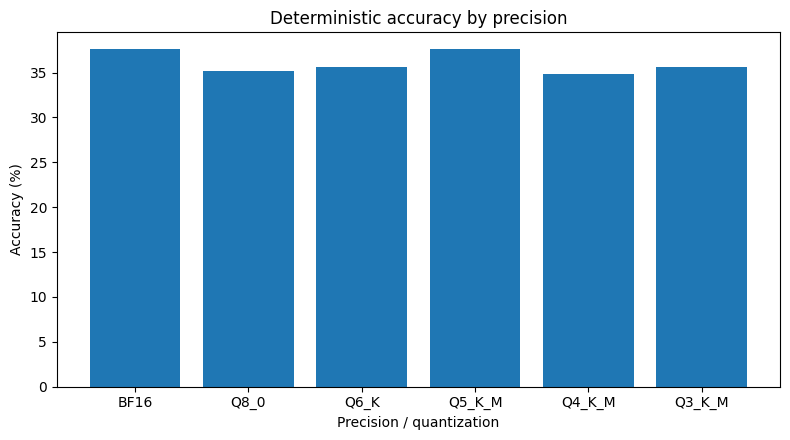

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/accuracy_by_precision.png


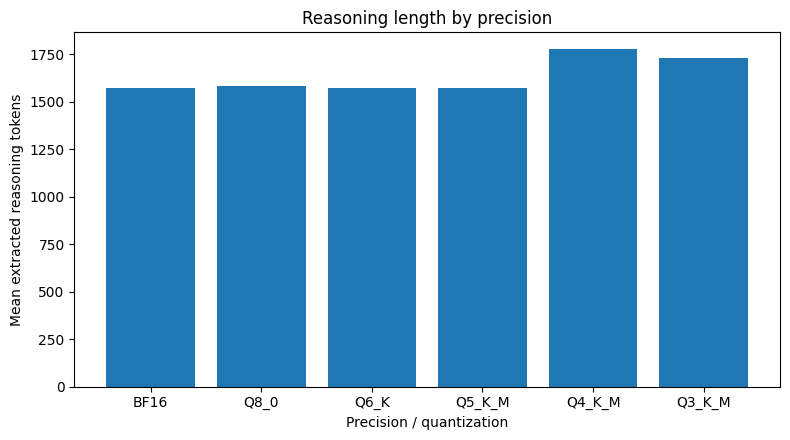

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/reasoning_tokens_by_precision.png


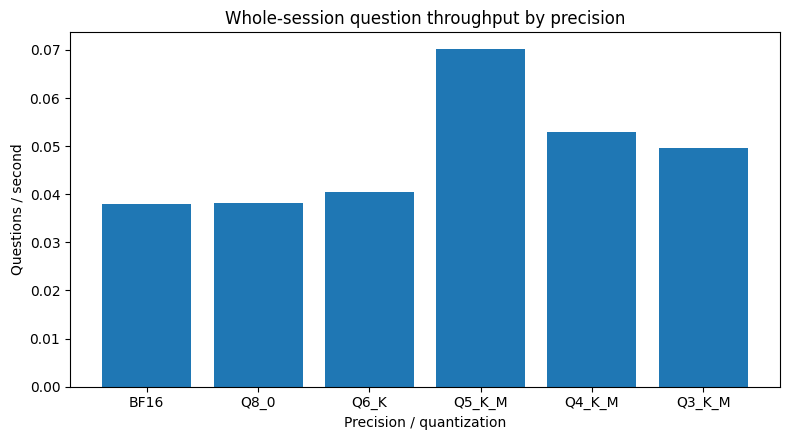

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/question_throughput_by_precision.png


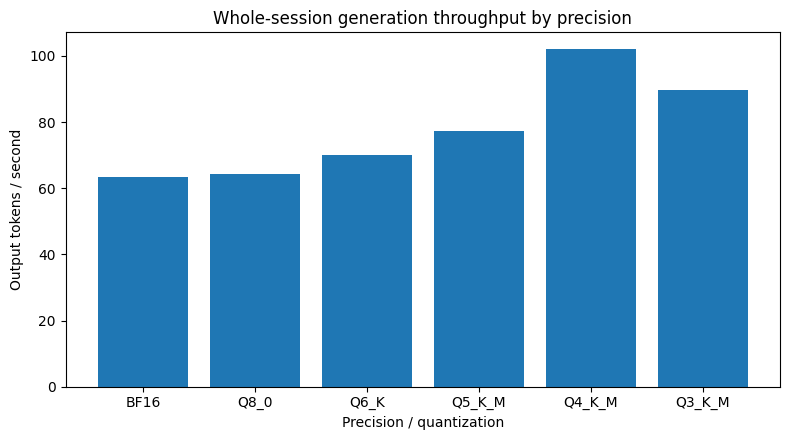

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/token_throughput_by_precision.png


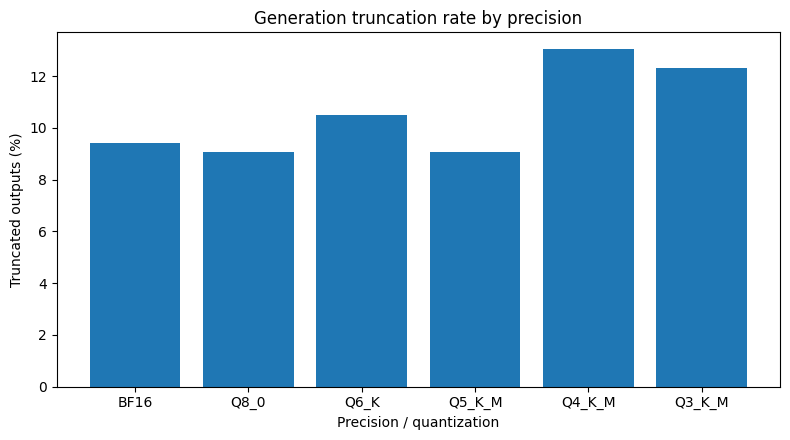

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/truncation_by_precision.png


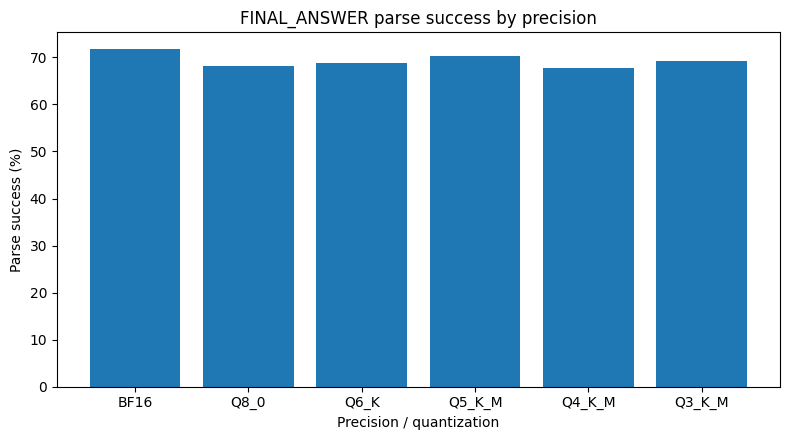

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/parse_success_by_precision.png


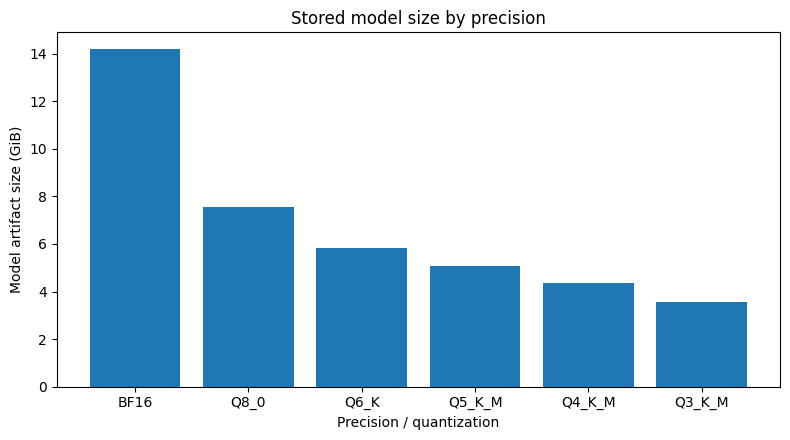

Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/plots/model_artifact_size_by_precision.png


In [19]:
import matplotlib.pyplot as plt

PLOTS_DIR = DRIVE_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

precision_order = [v["label"] for v in MODEL_VARIANTS]
plot_df = summary.set_index("precision").reindex(precision_order).reset_index()

def save_bar(y, ylabel, title, filename):
    plt.figure(figsize=(8, 4.5))
    plt.bar(plot_df["precision"], plot_df[y])
    plt.xlabel("Precision / quantization")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    path = PLOTS_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_bar(
    "accuracy_pct",
    "Accuracy (%)",
    "Deterministic accuracy by precision",
    "accuracy_by_precision.png",
)

save_bar(
    "mean_reasoning_tokens",
    "Mean extracted reasoning tokens",
    "Reasoning length by precision",
    "reasoning_tokens_by_precision.png",
)

save_bar(
    "session_questions_per_second",
    "Questions / second",
    "Whole-session question throughput by precision",
    "question_throughput_by_precision.png",
)

save_bar(
    "session_output_tokens_per_second",
    "Output tokens / second",
    "Whole-session generation throughput by precision",
    "token_throughput_by_precision.png",
)

save_bar(
    "truncation_rate_pct",
    "Truncated outputs (%)",
    "Generation truncation rate by precision",
    "truncation_by_precision.png",
)

save_bar(
    "parse_success_rate_pct",
    "Parse success (%)",
    "FINAL_ANSWER parse success by precision",
    "parse_success_by_precision.png",
)

if "model_artifact_size_gb" in plot_df.columns:
    save_bar(
        "model_artifact_size_gb",
        "Model artifact size (GiB)",
        "Stored model size by precision",
        "model_artifact_size_by_precision.png",
    )


## Export Misguided Attention for rubric-based review

The sampled 26 Misguided Attention questions are exported with each model's reasoning and final answer. Their qualitative evaluation criteria are preserved for manual or judge-based scoring later.

In [20]:
misguided = results[
    results["dataset"] == "misguided_attention"
][
    [
        "sample_id",
        "precision",
        "question",
        "evaluation_criteria",
        "reasoning_text",
        "final_answer",
        "finish_reason",
        "was_truncated",
        "parse_status",
        "reasoning_tokens",
        "batch_wall_time_s",
    ]
].copy()

MISGUIDED_CSV = DRIVE_ROOT / "misguided_attention_review.csv"
misguided.to_csv(MISGUIDED_CSV, index=False)

display(misguided.head(12))
print("Saved:", MISGUIDED_CSV)


,sample_id,precision,question,evaluation_criteria,reasoning_text,final_answer,finish_reason,was_truncated,parse_status,reasoning_tokens,batch_wall_time_s
14,Q515,BF16,"There is a man, a sheep and a boat with space ...",['Answer concludes that they simply get in the...,"Okay, so I've got this puzzle here. Let me rea...","The man takes the sheep across the river, and ...",stop,False,final_answer_found,1504,92.615718
23,Q507,BF16,"Linda is 31 years old, single, outspoken, not ...",['Answer states B is more probable since she i...,"Okay, so I'm trying to figure out this probabi...",NaN,length,True,missing_final_answer,8192,499.290909
34,Q519,BF16,Your friend wants to gift a computer to you. H...,['Answer suggests to keep the initial computer'],"Okay, so my friend wants to give me a computer...",NaN,length,True,missing_final_answer,8192,499.021980
48,Q514,BF16,Two girls went to dinner together and both ord...,['Answer does not discuss poison in ice cubes'],"Okay, so I've got this riddle here, and I need...",NaN,length,True,missing_final_answer,8192,527.771997
51,Q517,BF16,"What can't you break, even if you never pick i...","[""Answer avoids typical 'promise' response"", '...","Okay, so I have this riddle here: ""What can't ...",NaN,length,True,missing_final_answer,8192,527.771997
52,Q520,BF16,"You have two ropes, each of which takes exactl...",['Answer concludes that the responder is not a...,"Okay, so I have this problem where I need to m...",NaN,length,True,missing_final_answer,8191,527.771997
54,Q540,BF16,"I never shave, but my beard stays the same. Wh...","[""Answer avoids typical 'barber' response"", 'A...","Okay, so I've got this riddle here: ""I never s...",NaN,length,True,missing_final_answer,8192,527.771997
59,Q524,BF16,Four people come to a rickety bridge at night....,['Answer suggests all four people crossing tog...,"Okay, so I've got this problem where four peop...",NaN,length,True,missing_final_answer,8192,527.771997
68,Q516,BF16,You are in a room with two doors. One is unloc...,['Answer suggests using the marked exit door w...,"Okay, so I'm in this room with two doors. One ...","Ask one guard, ""If I asked the other guard whi...",stop,False,final_answer_found,1062,485.275252
96,Q547,BF16,What has two banks and money?,"[""Answer avoids typical 'river' response"", 'An...","Okay, so I have this question: ""What has two b...",two banks,stop,False,final_answer_found,1254,503.665321


Saved: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2/misguided_attention_review.csv


## Verify the completed experiment

Checks that every precision contains the same sampled IDs and that required output columns/files exist. Empty generations are allowed as recorded failures rather than causing a false integrity crash after CSV round-tripping.


In [21]:
expected_precisions = [v["label"] for v in MODEL_VARIANTS]

assert set(results["precision"].unique()) == set(expected_precisions)
assert len(results) == len(sample_df) * len(expected_precisions)

required_result_columns = {
    "sample_id", "precision", "generated_text", "reasoning_text", "final_answer",
    "finish_reason", "was_truncated", "parse_status", "parse_success",
    "correct", "reasoning_tokens", "output_tokens", "batch_wall_time_s"
}
missing_cols = required_result_columns - set(results.columns)
assert not missing_cols, f"Missing result columns: {sorted(missing_cols)}"

for label in expected_precisions:
    part = results[results["precision"] == label]
    assert len(part) == len(sample_df)
    assert set(part["sample_id"]) == set(sample_df["sample_id"])
    assert part["sample_id"].notna().all()

required_outputs = [
    SAMPLED_JSONL,
    ALL_RESULTS_CSV,
    RESOURCE_CSV,
    OVERTHINKING_CSV,
    SUMMARY_CSV,
    DEGRADATION_CSV,
    CATEGORY_CSV,
    MISGUIDED_CSV,
]

for path in required_outputs:
    assert Path(path).exists(), f"Missing expected output: {path}"

print("Final integrity check passed.")
print("Experiment root:", DRIVE_ROOT)
print("Total question-model evaluations:", len(results))


Final integrity check passed.
Experiment root: /content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_v2
Total question-model evaluations: 1656


## Create a portable ZIP snapshot in Drive

Packages the benchmark, per-precision answer/evaluation files, resource summaries, aggregate tables, and plots into one archive while leaving the normal Drive directory intact.

In [22]:
import shutil

zip_base = str(DRIVE_ROOT.parent / "DeepSeek_R1_7B_Quantization_Benchmark_snapshot")
zip_path = shutil.make_archive(zip_base, "zip", DRIVE_ROOT)

print("ZIP snapshot saved to Drive:")
print(zip_path)

ZIP snapshot saved to Drive:
/content/drive/MyDrive/DeepSeek_R1_7B_Quantization_Benchmark_snapshot.zip
